# Vélib Station Fill Rate Prediction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pastis-ai/velib-predict-dispo/blob/main/starter.ipynb)

**Challenge:** predict `taux_remplissage` (fill rate) for Paris Vélib stations.

$$\text{taux\_remplissage} = \frac{\text{numbikesavailable}}{\text{capacity}} \in [0.0,\; 1.0]$$

- `0.0` — station completely empty, no bikes available
- `1.0` — station completely full, no docks available
- `0.25` — 25 % of capacity has bikes (e.g. 3 bikes on a 12-dock station)

**Why this target?** It carries more information than a binary "has\_bike" flag:
knowing a station is at 20 % capacity tells you far more than "not empty."

**Metric:** Brier Score = MSE between predictions and true fill rate.  
Lower is better. **Leaderboard score = (1 − BS) × 100** — higher is better.

## 0. Setup

**Running on Google Colab?** The first code cell installs the exact library
versions used by the Pastis.ai scoring sandbox. Because this downgrades numpy,
Colab must **restart the runtime once** — when it does, simply **re-run that
same cell**, then continue. (Running locally with the project `.venv`? Nothing
to install — just run the cells.)

In [1]:
# --- Colab setup: clone the repo + install the sandbox-pinned dependencies ---
#
# Google Colab ships numpy 2.x pre-loaded, but the Pastis.ai scoring sandbox
# runs the EXACT versions pinned in requirements.txt (numpy 1.26.4,
# scikit-learn 1.4.0, pandas 2.2.0). Training with mismatched versions can
# produce a submission.pkl that fails to load in the sandbox, so we install
# the pinned versions here.
#
# Downgrading numpy inside a running kernel makes the already-imported numpy
# binary-incompatible with the freshly installed pandas/sklearn (the classic
# "ValueError: numpy.dtype size changed" crash). The only fix is to restart the
# runtime once. This cell does that automatically and is safe to re-run.
import os
import sys
import subprocess

if "google.colab" in sys.modules:
    if not os.path.isdir("velib-predict-dispo"):
        subprocess.run(
            ["git", "clone", "--quiet",
             "https://github.com/pastis-ai/velib-predict-dispo.git"],
            check=True,
        )
    os.chdir("velib-predict-dispo")

    import numpy
    if numpy.__version__ != "1.26.4":
        print("Installing sandbox-pinned dependencies (~1 min)...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
            check=True,
        )
        print("\nDone. Restarting the runtime to load the pinned versions.")
        print("=> When it restarts, RE-RUN THIS CELL once, then continue.")
        sys.stdout.flush()  # make sure the message shows before the hard restart
        os.kill(os.getpid(), 9)
    else:
        print("Colab ready -- sandbox-pinned dependencies are active.")
else:
    print("Local environment detected -- using your existing .venv.")

Local environment detected -- using your existing .venv.


In [2]:
import time
import warnings
import cloudpickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

from pastis_velib import (
    make_basic_features,
    compute_target,
    brier_score_local,
    verify_submission,
)

DATA_PATH = 'velib_dataset_dev.csv'
API_BASE  = 'https://pastis.ai/api/scenarios/velib-predict-dispo'

print('Setup complete.')

/var/folders/kn/1jrq60v96t5bv9z2xcymm56r0000gn/T/ipykernel_77965/260915942.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Setup complete.


### What just happened?

You imported the tools for this challenge:
- **pandas / numpy** — data manipulation and math
- **matplotlib / seaborn** — visualization
- **pastis_velib** — the Pastis.ai library that defines the submission contract

`DATA_PATH` points to the local CSV. If it doesn't exist, the loading code below
downloads it from the Pastis API automatically — no manual setup needed.

`API_BASE` is the URL of the Pastis backend — the same server that will score
your submission when you upload `submission.pkl`.

## 1. The Data

The Paris Vélib API snapshots all ~1,400 stations every 30 minutes.  
Each row in our dataset is **one station at one point in time**.

| Column | Type | Description |
|--------|------|-------------|
| `stationcode` | str | Unique station identifier |
| `name` | str | Human-readable station name |
| `snapshot_at` | datetime | When this measurement was taken |
| `capacity` | int | Total number of docks at the station |
| `numbikesavailable` | int | Bikes currently available |
| `mechanical` | int | Classic (non-electric) bikes available |
| `ebike` | int | Electric bikes available |
| `numdocksavailable` | int | Free docking slots |
| `is_renting` | str | "OUI" if station is currently renting |
| `nom_arrondissement_communes` | str | Paris arrondissement |
| `coordonnees_geo` | str | `{"lon": ..., "lat": ...}` |
| `has_bike` | int | 1 if at least one bike available (derived) |

**Target:** `taux_remplissage = numbikesavailable / capacity`

This column is **not in the raw data** — we compute it.  
The sandbox computes it the same way to score your submission.

> **Data leakage warning:** `numbikesavailable`, `mechanical`, `ebike`, and
> `numdocksavailable` directly reveal the target. Do not use them as features
> unless you are working deliberately with lagged values.

In [3]:
# Load local CSV; fall back to API download if not found
if os.path.exists(DATA_PATH):
    print(f'Loading {DATA_PATH} ...')
    df = pd.read_csv(DATA_PATH, parse_dates=['snapshot_at'])
else:
    print('Local file not found — downloading from Pastis API...')
    import requests
    params = {
        'date_from': '2026-04-14',
        'date_to':   '2026-04-30',
        'arrondissements': ['Paris 18e', 'Paris 19e', 'Paris 20e'],
    }
    with requests.get(
        f'{API_BASE}/download', params=params, stream=True, timeout=300
    ) as r:
        r.raise_for_status()
        with open(DATA_PATH, 'wb') as f_out:
            for chunk in r.iter_content(chunk_size=8192):
                f_out.write(chunk)
    df = pd.read_csv(DATA_PATH, parse_dates=['snapshot_at'])

print(f'Rows            : {len(df):,}')
print(f'Stations        : {df["stationcode"].nunique()}')
print(f'Arrondissements : {df["nom_arrondissement_communes"].nunique()}')
print(f'Date range      : {df["snapshot_at"].min()} → {df["snapshot_at"].max()}')
df.head()

Loading velib_dataset_dev.csv ...
Rows            : 42,367
Stations        : 67
Arrondissements : 1
Date range      : 2026-04-14 00:08:09 → 2026-04-30 23:36:14


,stationcode,name,snapshot_at,capacity,numbikesavailable,mechanical,ebike,numdocksavailable,is_renting,nom_arrondissement_communes,coordonnees_geo,has_bike
0,20001,Place de la Nation - Charonne,2026-04-14 00:08:09,36,14,10,4,21,OUI,Paris,"{'lon': 2.3997623859813, 'lat': 48.848364667777}",1
1,20002,Square de la rue Pixérécourt,2026-04-14 00:08:09,45,8,1,7,37,OUI,Paris,"{'lon': 2.3960278, 'lat': 48.8736824}",1
2,20003,Pyrénées - Cours de Vincennes,2026-04-14 00:08:09,21,7,4,3,12,OUI,Paris,"{'lon': 2.4061721563339, 'lat': 48.847796779935}",1
3,20004,Commandant l'Herminier - Gallieni,2026-04-14 00:08:09,17,5,3,2,12,OUI,Paris,"{'lon': 2.4160453677177, 'lat': 48.847040552603}",1
4,20005,Reynaldo Hahn - Lagny,2026-04-14 00:08:09,19,2,2,0,17,OUI,Paris,"{'lon': 2.412330328844772, 'lat': 48.849266043...",1


In [4]:
# Compute the prediction target (not in raw data — we derive it)
df['taux_remplissage'] = (
    df['numbikesavailable'] / df['capacity'].replace(0, float('nan'))
).fillna(0.0).clip(0.0, 1.0)

print('Target distribution (taux_remplissage):')
print(f'  mean : {df["taux_remplissage"].mean():.1%}')
print(f'  std  : {df["taux_remplissage"].std():.1%}')
print(f'  min  : {df["taux_remplissage"].min():.1%}')
print(f'  25%  : {df["taux_remplissage"].quantile(0.25):.1%}')
print(f'  50%  : {df["taux_remplissage"].quantile(0.50):.1%}')
print(f'  75%  : {df["taux_remplissage"].quantile(0.75):.1%}')
print(f'  max  : {df["taux_remplissage"].max():.1%}')

Target distribution (taux_remplissage):
  mean : 20.8%
  std  : 19.8%
  min  : 0.0%
  25%  : 5.3%
  50%  : 14.6%
  75%  : 30.3%
  max  : 100.0%


### Reading the target distribution

Look at these numbers carefully:
- **mean ≈ 20.8%** — on average, stations are only 1/5 full in these arrondissements
- **std ≈ 19.8%** — almost as large as the mean — there is real spread to predict
- **min: 0% / max: 100%** — the full range is present in the data
- **median ≈ 14.6%** — half the snapshots have stations below 15% capacity

This is very different from the 1st arrondissement (99% full at all times).  
These outer arrondissements have genuine demand pressure — stations drain and refill  
throughout the day. **This is why ML can add value here.**

If the distribution were a spike at 1.0, any model that always predicts 1.0  
would look great on metrics but tell you nothing useful. Here, there is real  
variance to explain — and that variance is what your model has to learn.

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
stationcode,42367.0,NaN,NaN,NaN,20071.840182,20001.0,20020.0,20043.0,20118.0,20205.0,60.231668
name,42367,67,Charonne - Avron,633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snapshot_at,42367,NaN,NaN,NaN,2026-04-23 16:21:55.082162944,2026-04-14 00:08:09,2026-04-20 12:00:20,2026-04-23 20:32:14,2026-04-27 03:34:08,2026-04-30 23:36:14,NaN
capacity,42367.0,NaN,NaN,NaN,27.976916,12.0,21.0,26.0,33.0,50.0,8.874847
numbikesavailable,42367.0,NaN,NaN,NaN,5.608398,0.0,2.0,4.0,8.0,42.0,5.489833
mechanical,42367.0,NaN,NaN,NaN,1.55928,0.0,0.0,0.0,2.0,27.0,2.904525
ebike,42367.0,NaN,NaN,NaN,4.049118,0.0,1.0,3.0,6.0,31.0,4.145699
numdocksavailable,42367.0,NaN,NaN,NaN,21.87318,0.0,16.0,21.0,27.0,50.0,9.305897
is_renting,42367,1,OUI,42367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nom_arrondissement_communes,42367,1,Paris,42367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Explore the Data

These five charts are not decorative — each one motivates a feature engineering decision.  
Read the **Why** caption and the **What this tells you** interpretation after each chart.

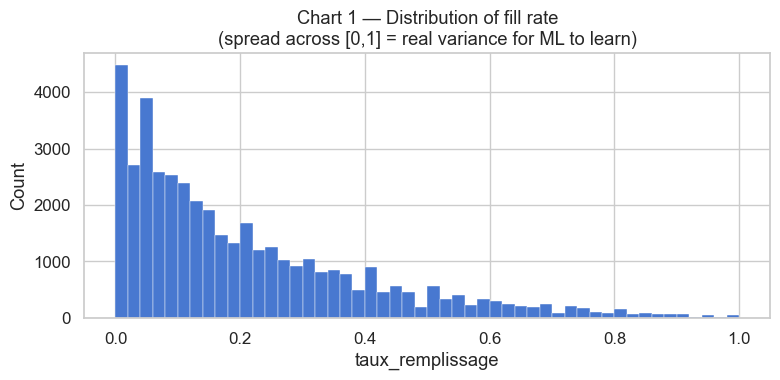

In [6]:
# Chart 1 — Distribution of taux_remplissage
# Why: if the target is spread across [0, 1], ML has something real to learn.
# A spike at 0.0 or 1.0 signals a trivial imbalance — same problem as
# predicting has_bike in a wealthy arrondissement where stations are never empty.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['taux_remplissage'], bins=50, edgecolor='white', linewidth=0.3)
ax.set_xlabel('taux_remplissage')
ax.set_ylabel('Count')
ax.set_title(
    'Chart 1 — Distribution of fill rate\n'
    '(spread across [0,1] = real variance for ML to learn)'
)
plt.tight_layout()
plt.show()

**What this tells you:** The distribution is right-skewed — many stations
are nearly empty (spike near 0) and fewer are nearly full. This means your model
will see many more low-fill-rate examples than high-fill-rate examples during training.
If it struggles to predict high fill rates, this imbalance is why.

**On more data** (longer time range) you would see this distribution shift with seasons:
April has moderate demand. Winter has lower demand (more full stations).
Summer peaks have higher demand (emptier stations). More temporal diversity
gives the model a richer training distribution and better generalization.

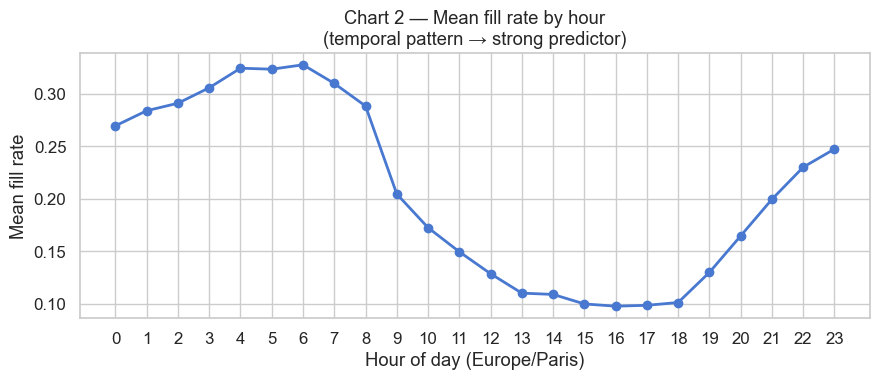

In [7]:
# Chart 2 — Mean fill rate by hour of day (Paris local time)
# Why: the strongest temporal signal.
# Expect dips at commute hours (8–9am, 5–7pm) — people take bikes from stations.
# If the chart is flat, hour is not a useful feature for this data.
#
# snapshot_at is raw UTC, so we convert it to Europe/Paris first: "hour 8" then
# means 8am on the Paris wall clock — the clock commuters actually live by. This
# matches the `hour` feature in make_basic_features() (see the timezone note in
# Section 3).
hour_paris = (
    pd.to_datetime(df['snapshot_at'], utc=True)
      .dt.tz_convert('Europe/Paris')
      .dt.hour
)
hourly = df.groupby(hour_paris)['taux_remplissage'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2)
ax.set_xlabel('Hour of day (Europe/Paris)')
ax.set_ylabel('Mean fill rate')
ax.set_xticks(range(0, 24))
ax.set_title('Chart 2 — Mean fill rate by hour\n(temporal pattern → strong predictor)')
plt.tight_layout()
plt.show()

**What this tells you:** There is a clear intraday pattern.
Stations drain from early morning to ~noon (people taking bikes to work and leisure).
They gradually refill through the afternoon and evening as bikes are returned.

**What this means for features:** `hour` will likely be your strongest predictor.
The model will learn "at hour 8, this station is typically at 10% capacity."
If you see a flat line here, `hour` adds little value — but on the 18e/19e/20e
arrondissements with real commuting pressure, the pattern should be clear.

**What to look for on more data:** The curve shape may differ by season.
Winter mornings may have a shallower dip; summer afternoons may drain harder.
With only 2.5 weeks, you are seeing April behavior — which may not generalize.

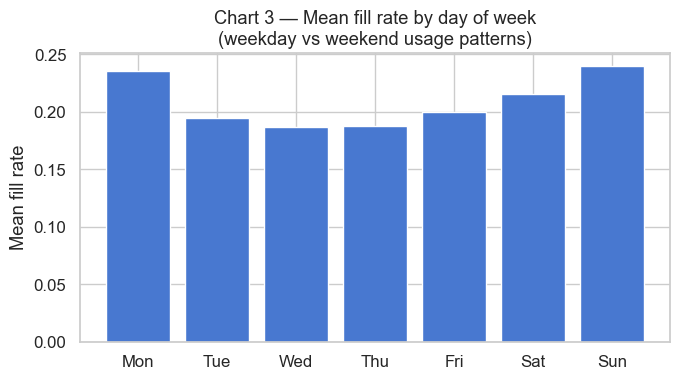

In [8]:
# Chart 3 — Mean fill rate by day of week (Paris local time)
# Why: weekday vs weekend usage patterns are fundamentally different.
# Commuter rush (Mon–Fri) vs leisure cycling (Sat–Sun).
# As in Chart 2, we read the day off the Paris wall clock, not UTC.
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_paris = (
    pd.to_datetime(df['snapshot_at'], utc=True)
      .dt.tz_convert('Europe/Paris')
      .dt.dayofweek
)
daily = df.groupby(dow_paris)['taux_remplissage'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(daily.index, daily.values)
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_ylabel('Mean fill rate')
ax.set_title('Chart 3 — Mean fill rate by day of week\n(weekday vs weekend usage patterns)')
plt.tight_layout()
plt.show()

**What this tells you:** The difference between weekdays and weekends reflects
two fundamentally different cycling behaviors:
- **Weekdays** — commuters drain stations in waves during rush hours
- **Weekends** — leisure cyclists spread demand more evenly across the day

The `is_weekend` binary feature in `make_basic_features()` captures this split.
For finer control, encode each day separately (the `dayofweek` feature already does this).

**If the bars look similar across days:** the dataset may not have enough days
to show a clear weekday/weekend pattern statistically. With 2.5 weeks (~3 weekends),
the signal may be noisy. Download more months from the API for a cleaner picture.

/var/folders/kn/1jrq60v96t5bv9z2xcymm56r0000gn/T/ipykernel_77965/195977227.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


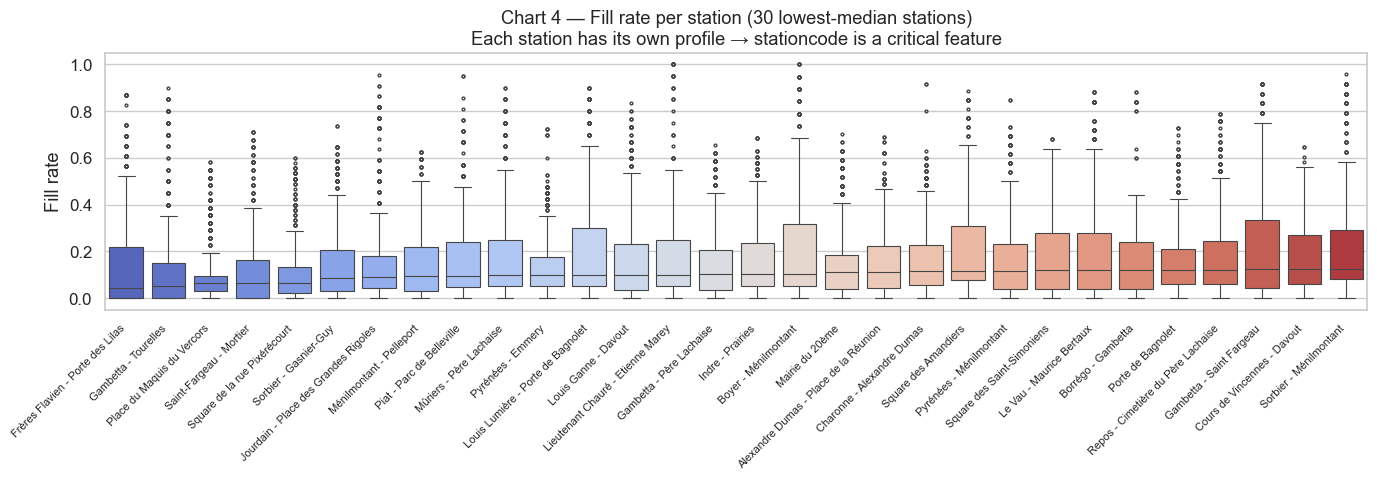

In [9]:
# Chart 4 — Fill rate distribution per station (boxplot) — THE KEY INSIGHT
# Why: each station has a structurally different fill rate.
# Some are chronically empty (near transit hubs); others are always full.
# → stationcode will be a critical feature in your model.
station_medians = df.groupby('name')['taux_remplissage'].median().sort_values()
top_stations = station_medians.index[:30].tolist()
plot_data = df[df['name'].isin(top_stations)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=plot_data, x='name', y='taux_remplissage',
    order=top_stations, ax=ax,
    palette='coolwarm', linewidth=0.8, fliersize=2,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('Fill rate')
ax.set_title(
    'Chart 4 — Fill rate per station (30 lowest-median stations)\n'
    'Each station has its own profile → stationcode is a critical feature'
)
plt.tight_layout()
plt.show()

**This is the most important chart.**

Look at the spread within each station (the box height = interquartile range).
- **Wide boxes** — the station's fill rate varies a lot throughout the day and week
- **Narrow boxes near 0** — the station is structurally almost always empty
- **Different medians** — each station has its own baseline fill rate

Two concrete takeaways:

1. **`stationcode` is a critical feature** — stations have structurally different
   profiles that persist over time. Without this feature, the model treats all
   stations as identical and cannot learn per-station patterns.

2. **Per-station historical mean fill rate** will be one of your most powerful
   features. It gives the model an anchor: "station X is typically at 8%,
   so even without temporal context, the prior is low." The `Going Further`
   section shows how to build this — and it is already implemented in `MyModel`.

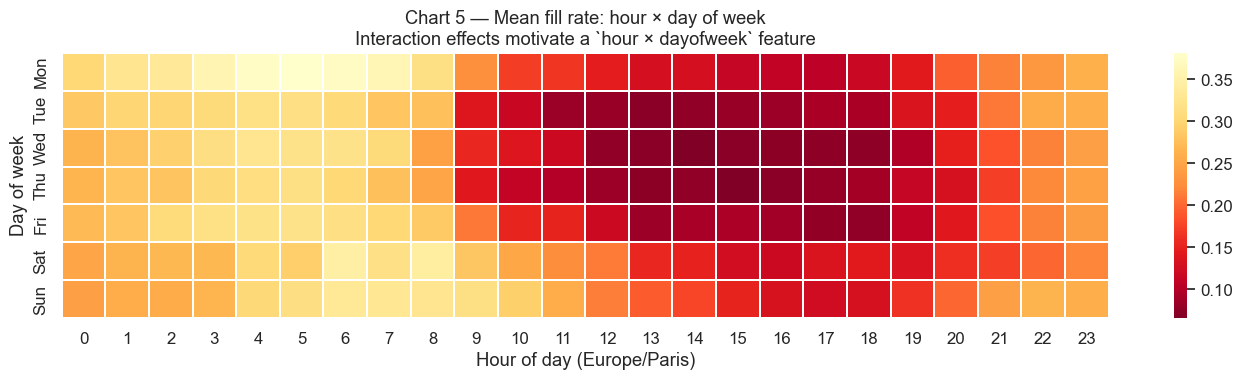

In [10]:
# Chart 5 — Heatmap: hour × day of week (Paris local time)
# Why: interactions matter. "8am on Friday" ≠ "8am on Sunday".
# This motivates an hour×dayofweek interaction feature.
# Both axes use Europe/Paris time, consistent with make_basic_features().
ts_paris = pd.to_datetime(df['snapshot_at'], utc=True).dt.tz_convert('Europe/Paris')
pivot = df.pivot_table(
    values='taux_remplissage',
    index=ts_paris.dt.dayofweek,
    columns=ts_paris.dt.hour,
    aggfunc='mean',
)
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd_r', ax=ax, linewidths=0.2, annot=False)
ax.set_xlabel('Hour of day (Europe/Paris)')
ax.set_ylabel('Day of week')
ax.set_title(
    'Chart 5 — Mean fill rate: hour × day of week\n'
    'Interaction effects motivate a `hour × dayofweek` feature'
)
plt.tight_layout()
plt.show()

**What this tells you:** The interaction between hour and day of week is real.
"Monday at noon" and "Sunday at noon" have measurably different fill rates.
A feature that encodes each `(hour, dayofweek)` combination captures this
interaction directly — something that `hour` and `dayofweek` separately cannot.

**What to try:** add this line in `make_features()` in `my_model.py`:
```python
features['hour_x_dow'] = features['hour'] * features['dayofweek']
```
This is a linear interaction proxy. It is not the same as one-hot encoding every
combination, but it is computationally cheap and often sufficient for tree models.

### What the data is telling you

From the five charts above, here is what you know before training any model:

**1. The target has real variance** (Chart 1)  
Mean ≈ 20.8%, std ≈ 19.8%, full [0,1] range present. ML has something genuine to learn —
this is not the trivial imbalance problem you would encounter with `has_bike` in the 1st arrondissement.

**2. Time of day is your strongest signal** (Chart 2)  
A clear intraday pattern driven by commuting behavior.
`hour` will dominate feature importance. If it doesn't, something is wrong.

**3. Station identity matters structurally** (Chart 4)  
The spread between stations is as large as the intraday pattern.
A model that doesn't know which station it's predicting for is missing
the most important spatial signal. `stationcode` must be in your features.

**4. Hour × day interaction is non-trivial** (Chart 5)  
Weekday rush hours are far more extreme than weekend patterns.
A simple `hour` feature treats Monday noon and Sunday noon equally — they're not.

**5. You only have 2.5 weeks of data** (Charts 2 & 3)  
The `month` feature will contribute nothing until you download more months.
With 4+ months available in the API, download more data before your final submission.

## 3. Feature Engineering

Feature engineering is the most impactful step in an ML pipeline.  
The model can only learn patterns that are present in the features you give it.

**What `make_basic_features()` gives you:**

| Feature | Source | Why it matters |
|---------|--------|----------------|
| `hour` | `snapshot_at` | Intraday demand pattern |
| `dayofweek` | `snapshot_at` | Weekday vs weekend |
| `is_weekend` | derived | Shortcut for weekday/weekend split |
| `month` | `snapshot_at` | Seasonal variation |
| `stationcode` | direct | Per-station identity |
| `capacity` | direct | Station size affects buffering |
| `arrondissement` | stationcode prefix | Neighborhood-level patterns |

**What NOT to use (data leakage):**  
`numbikesavailable`, `mechanical`, `ebike`, `numdocksavailable` — these directly reveal `taux_remplissage`.  
Using them as features means predicting from the answer, not from prior information.

**Temporal split — always:**  
Never use `train_test_split(shuffle=True)` on time series.  
Random split leaks future information into training, inflating local scores  
while the model fails on real unseen data.

In [11]:
# Show what make_basic_features produces
sample = df.head(3)
features_sample = make_basic_features(sample)

print('Raw columns     :', list(df.columns))
print('\nFeature columns :', list(features_sample.columns))
features_sample

Raw columns     : ['stationcode', 'name', 'snapshot_at', 'capacity', 'numbikesavailable', 'mechanical', 'ebike', 'numdocksavailable', 'is_renting', 'nom_arrondissement_communes', 'coordonnees_geo', 'has_bike', 'taux_remplissage']

Feature columns : ['hour', 'dayofweek', 'is_weekend', 'month', 'stationcode', 'capacity', 'arrondissement']


,hour,dayofweek,is_weekend,month,stationcode,capacity,arrondissement
0,2,1,0,4,20001,36,20
1,2,1,0,4,20002,45,20
2,2,1,0,4,20003,21,20


### What `make_basic_features()` gave you — and what it didn't

You now have 7 features for a dataset with ~42,000 rows and significant complexity.
That is a sparse representation of a rich problem.

**What's missing that could help:**
- **Per-station historical average fill rate** — the single most impactful addition.
  `MyModel` already computes this in `fit()` and adds it as `station_mean_rate`.
- **Hour × day of week interaction term** — captures the heatmap pattern from Chart 5
- **Rush hour binary flag** — simplified commute signal
- **Capacity bins** — small / medium / large station behavior differs structurally

**Why isn't this all already included?** Because choosing features is ML.
The baseline gives you a working pipeline. Beating it requires thinking about
what information the model actually needs — and that is your job.

The `Going Further` section at the bottom gives exact code for each improvement.

### Why `hour` and `dayofweek` use Paris local time

Look closely at the `hour` column above: the first rows were captured at `00:08`
in the raw `snapshot_at`, yet `make_basic_features()` reports `hour = 2`. That is
deliberate — and it is one of the most important modelling decisions in this kit.

**The raw `snapshot_at` is in UTC.** But Vélib demand follows the human wall
clock, not UTC: the morning commute drains stations at **8am Paris time**, every
day of the year. So `make_basic_features()` converts each timestamp from UTC to
the `Europe/Paris` zone *before* extracting `hour` and `dayofweek`.

**Why this matters — daylight saving time (DST).** Paris is `UTC+1` in winter and
`UTC+2` in summer. If you fed the model the raw UTC hour, "8am Paris" would land
on UTC hour 7 in winter but UTC hour 6 in summer — your single most predictive
signal would be **smeared across two different hours depending on the season**.
Converting to `Europe/Paris` (an IANA zone that already knows the DST rules) pins
the commute peak to the same `hour` value all year. Never hard-code a fixed
offset like `+1` or `+2`: it would be wrong for half the year.

**A caveat honest to this dataset.** `velib_dataset_dev.csv` covers only
14–30 April 2026 — entirely inside summer time — so here UTC and Paris differ by a
constant `+2h` and the leaderboard score barely moves either way (a tree just
shifts its split thresholds). The payoff appears the moment you pull several
months from the API (*Going Further → Level 4*): a range that crosses the
late-March DST switch blurs the peak under raw UTC but stays crisp once
converted. We do the right thing now so your pipeline keeps working when you
scale the data up.

> **Takeaway:** when a feature encodes *human* behaviour, derive it from the clock
> those humans actually read. A time zone is a modelling decision, not a
> formatting detail.

In [12]:
def temporal_split(df, test_fraction=0.2):
    """Temporal split — never random on time series."""
    df = df.sort_values('snapshot_at').reset_index(drop=True)
    idx = int(len(df) * (1 - test_fraction))
    return df.iloc[:idx].copy(), df.iloc[idx:].copy()

df_train, df_test = temporal_split(df, test_fraction=0.2)

y_train = compute_target(df_train)
y_test  = compute_target(df_test)

print(f'Train : {len(df_train):,} rows | {df_train["snapshot_at"].min().date()} → {df_train["snapshot_at"].max().date()}')
print(f'Test  : {len(df_test):,}  rows | {df_test["snapshot_at"].min().date()} → {df_test["snapshot_at"].max().date()}')
print(f'\nTrain target — mean: {y_train.mean():.3f}  std: {y_train.std():.3f}')
print(f'Test  target — mean: {y_test.mean():.3f}  std: {y_test.std():.3f}')

Train : 33,893 rows | 2026-04-14 → 2026-04-27
Test  : 8,474  rows | 2026-04-27 → 2026-04-30

Train target — mean: 0.213  std: 0.200
Test  target — mean: 0.186  std: 0.191


## 4. Baseline

Before training any model, define what **doing nothing** looks like.  
A model that cannot beat this baseline has learned nothing useful.

**Our baseline:** always predict the mean fill rate from the training set.

This is stronger than always predicting `0.5` because:
- It uses the actual distribution of the target
- It still represents a model that has learned *nothing about individual stations or times*

Mathematically: `BS_baseline ≈ Var(y_test)` — approximately the variance of the target.

In [13]:
baseline_pred_value = y_train.mean()
baseline_preds = np.full(len(y_test), baseline_pred_value)

print(f'Baseline always predicts: {baseline_pred_value:.4f}')
print()
bs_baseline = brier_score_local(y_test.values, baseline_preds, label='Naive baseline')
print()
print(f'(Target variance in test: {float(y_test.var()):.4f})')

Baseline always predicts: 0.2132

Naive baseline — Brier Score      : 0.0371  (lower is better)
Naive baseline — Leaderboard score: 96.29 (higher is better)

(Target variance in test: 0.0363)


### Why is the baseline score already so high?

A baseline score around 96 surprises most people. If baseline = 96 and a good model
scores 97–98, why bother with ML at all?

**The score range matters, not the absolute value.**

With a target that has mean ≈ 0.21 and std ≈ 0.20, the Brier Score (which is MSE)
is bounded by the variance of the target — approximately 0.04 for this dataset.
A perfect model scores 0.00; a naive model scores ≈ 0.04.
That is a very small absolute range.

Translated to the `(1 − BS) × 100` leaderboard scale, everything is compressed  
between 96 and 100. **The gap between baseline and a good model is 1–4 points.**  
That gap is where the competition lives.

When you download 4 months of data across many arrondissements, the variance increases,  
the baseline drops, and the competitive range widens. The leaderboard becomes  
more meaningful — and harder to top — as the dataset grows.

## 5. Your Model

`MyModel` in `my_model.py` wraps a sklearn `HistGradientBoostingRegressor`.

When you write `model = MyModel()`, the instance has two relevant levels:
- `model` — the `MyModel` instance (the Pastis wrapper)
- `model.model` — the **sklearn `HistGradientBoostingRegressor` inside** `MyModel`

This double `.model` is intentional: `MyModel` adds the Pastis contract  
(`fit` / `predict` on raw DataFrames) on top of the sklearn estimator.  
When you access feature importances or sklearn internals, you need `model.model`.

**The fit → predict flow:**

```
model.fit(df_raw)
    ↓ compute per-station mean fill rate → self.station_means
    ↓ make_features(df_raw)              ← feature engineering + station_mean_rate
    ↓ compute_target(df_raw)             ← taux_remplissage = numbikesavailable / capacity
    ↓ self.model.fit(X, y)               ← HistGradientBoostingRegressor.fit()

model.predict(df_raw)
    ↓ make_features(df_raw)              ← same features as in fit
    ↓ self.model.predict(X)              ← gradient boosting predictions
    ↓ np.clip(..., 0.0, 1.0)             ← enforce output contract [0, 1]
```

In [14]:
from my_model import MyModel

model = MyModel()

# model.model is the sklearn HistGradientBoostingRegressor inside MyModel
print(f'Underlying estimator : {type(model.model).__name__}')
print(f'Hyperparameters      : {model.model.get_params()}')

t0 = time.time()
model.fit(df_train)
print(f'\nTraining done in {time.time() - t0:.1f}s')

y_pred = model.predict(df_test)
print(f'\nPredictions — min: {y_pred.min():.3f} | max: {y_pred.max():.3f} | mean: {y_pred.mean():.3f}')
print()
bs_model = brier_score_local(y_test.values, y_pred, label='MyModel')

Underlying estimator : HistGradientBoostingRegressor
Hyperparameters      : {'categorical_features': 'warn', 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_bins': 255, 'max_depth': 6, 'max_features': 1.0, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'quantile': None, 'random_state': 42, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}



Training done in 5.8s

Predictions — min: 0.009 | max: 0.725 | mean: 0.202

MyModel — Brier Score      : 0.0230  (lower is better)
MyModel — Leaderboard score: 97.70 (higher is better)


### Reading the training output

**Predicted max is below 1.0** — this is expected behavior for tree-based regressors.
Unless a leaf node contains only samples with fill rate = 1.0, it will predict less.
Gradient boosting is better at extremes than RandomForest (which averages leaf values),
but it still cannot predict values it hasn't seen in leaves during training.

`np.clip(..., 0.0, 1.0)` in `predict()` enforces the output contract but cannot
push predictions *up* — it only clamps values that exceeded 1.0.

**What this means in practice:** the model is conservative at very high fill rates.
When a station is truly full (actual = 1.0), it will underestimate.
The "Predicted vs Actual" chart in Section 6 will show this clearly.

**To partially fix this:** add features that directly signal high fill rate,
like time-of-day combinations known to correlate with full stations.
Or download more months of data to expose the model to more full-station examples.

In [15]:
print(f'Baseline BS : {bs_baseline:.4f}  (score: {(1-bs_baseline)*100:.2f})')
print(f'MyModel  BS : {bs_model:.4f}  (score: {(1-bs_model)*100:.2f})')
print()

if bs_model >= bs_baseline:
    print('⚠  Model does not beat baseline — check your features')
elif bs_model < 0.005:
    improvement_pct = (bs_baseline - bs_model) / bs_baseline * 100
    print(f'⚠  Very low Brier Score — verify there is no data leakage')
    print(f'   ({improvement_pct:.1f}% improvement over baseline — may still be valid)')
else:
    improvement_pct = (bs_baseline - bs_model) / bs_baseline * 100
    print(f'✓  {improvement_pct:.1f}% improvement over baseline')

Baseline BS : 0.0371  (score: 96.29)
MyModel  BS : 0.0230  (score: 97.70)

✓  37.9% improvement over baseline


## 6. Evaluation

Three charts to understand where your model succeeds and where it fails.

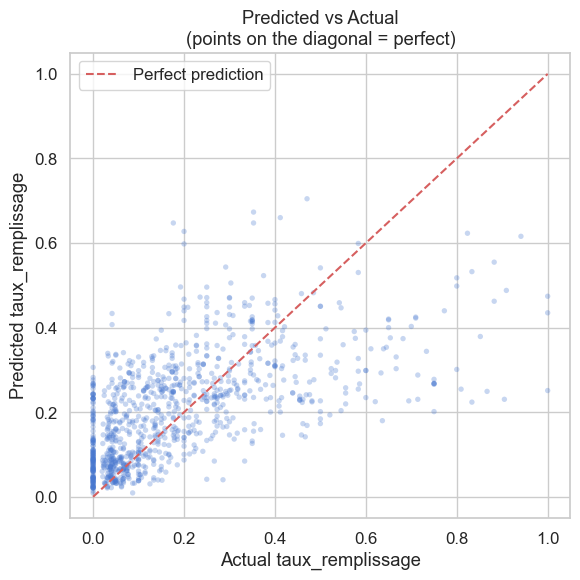

In [16]:
# Chart: predicted vs actual (sample 1000 points for readability)
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(y_test), size=min(1000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    y_test.values[idx_sample], y_pred[idx_sample],
    alpha=0.3, s=15, edgecolors='none'
)
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual taux_remplissage')
ax.set_ylabel('Predicted taux_remplissage')
ax.set_title('Predicted vs Actual\n(points on the diagonal = perfect)')
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

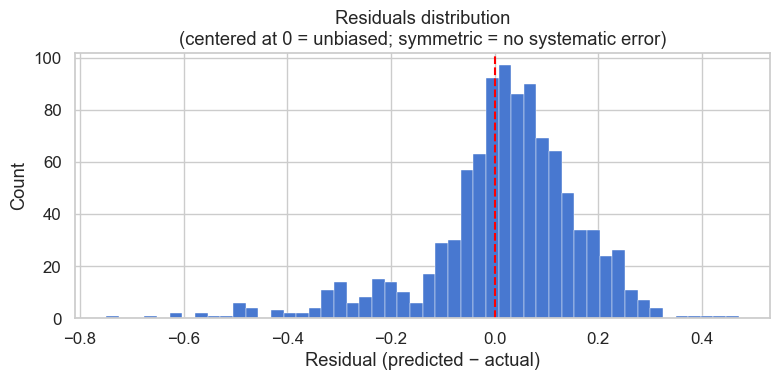

In [17]:
# Chart: residuals distribution (y_pred - y_true)
residuals = y_pred[idx_sample] - y_test.values[idx_sample]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=50, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual (predicted − actual)')
ax.set_ylabel('Count')
ax.set_title('Residuals distribution\n(centered at 0 = unbiased; symmetric = no systematic error)')
plt.tight_layout()
plt.show()

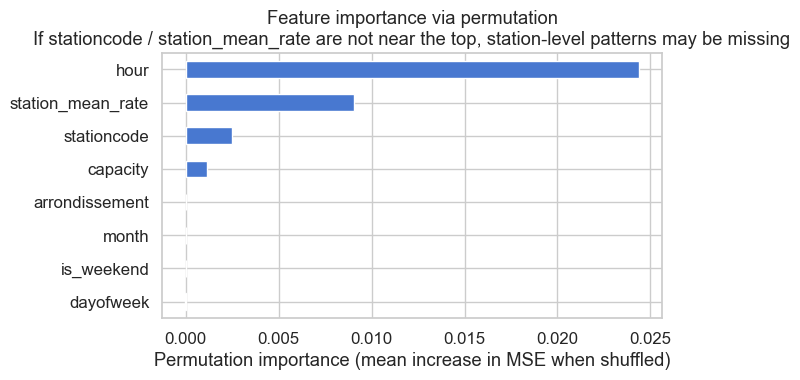

In [18]:
# Chart: feature importances via permutation importance
#
# HistGradientBoostingRegressor does NOT expose `feature_importances_`
# (unlike RandomForest or the classic GradientBoosting). The model-agnostic way
# to measure importance is permutation_importance: shuffle one feature column at
# a time and measure how much the score gets worse. Bigger drop = more important.
from sklearn.inspection import permutation_importance

X_test = model.make_features(df_test)

perm = permutation_importance(
    model.model, X_test, y_test.values,
    n_repeats=10, random_state=42,
    scoring="neg_mean_squared_error",  # aligns with the Brier Score metric
)

imp_series = (
    pd.Series(perm.importances_mean, index=X_test.columns)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
imp_series.plot(kind="barh", ax=ax)
ax.set_xlabel("Permutation importance (mean increase in MSE when shuffled)")
ax.set_title(
    "Feature importance via permutation\n"
    "If stationcode / station_mean_rate are not near the top, "
    "station-level patterns may be missing"
)
plt.tight_layout()
plt.show()

### Reading the evaluation charts

**Predicted vs Actual**

A perfect model puts all points on the red diagonal.
What you typically see instead:
- **Points cluster in the lower-left** (low actual, low predicted) — the model handles
  empty stations reasonably well since most training examples are near-empty
- **Points scatter above the diagonal at high actual values** — when a station is
  genuinely full (actual > 0.6), the model underestimates it
- **No points near (1.0, 1.0)** — the model rarely predicts "completely full"

This is typical of gradient boosting on right-skewed training data.
The fix: add `station_mean_rate` as a feature (already in `MyModel`) and
download more data so the model sees more full-station examples.

**Residuals distribution**

Centered near 0 — no systematic bias overall.  
A tail at negative values represents moments when a station was nearly full
but the model predicted near-empty. These are the hard cases: structurally
low-fill-rate stations that occasionally fill up at unusual times.

**Feature importance**

Expected ranking with the current features:
- **`station_mean_rate`** — strongest signal: where is this station typically?
- **`hour`** — confirmed strongest temporal signal, matches Chart 2
- **`stationcode`** — station identity matters, matches Chart 4
- **`capacity`** — station size is informative
- **`dayofweek`** — day-of-week adds info on top of hour
- **`arrondissement`** — neighborhood context
- **`month`, `is_weekend`** — low with only 2.5 weeks of April data

If `stationcode` or `station_mean_rate` is not in the top features,
station-level patterns are not being captured — which is the most important spatial signal.

## 7. Export & Submit

Once you are satisfied with your model, retrain on the **full dataset**  
(not just the train split) and export `submission.pkl`.

Retraining on the full dataset gives the model access to more data,  
which should improve generalization on the leaderboard test set.

In [19]:
# Retrain on the full dataset
print('Retraining on full dataset...')
t0 = time.time()
model_final = MyModel()
model_final.fit(df)
print(f'Done in {time.time() - t0:.1f}s')

# Export
import my_model as _my_model_module
import pastis_velib as _pastis_velib_module
cloudpickle.register_pickle_by_value(_my_model_module)
cloudpickle.register_pickle_by_value(_pastis_velib_module)

with open('submission.pkl', 'wb') as f:
    cloudpickle.dump(model_final, f)
print('Saved: submission.pkl')

# Verify
result = verify_submission('submission.pkl')
print(f'\nValid   : {result["valid"]}')
print(f'Message : {result["message"]}')
print(f'Sample  : {result["sample_output"]}')

Retraining on full dataset...


Done in 1.9s
Saved: submission.pkl

Valid   : True
Message : Submission is valid. Ready to upload to pastis.ai.
Sample  : [0.24763716659339627, 0.1842335334480524, 0.246701639927884, 0.32145108601074757, 0.3515925421818002]


### Submit to Pastis.ai

1. Run `python my_model.py` in your terminal to train and export `submission.pkl`
2. Open the [submission page](https://pastis.ai/scenarios/velib-predict-dispo?tab=submit)
3. Upload `submission.pkl`
4. Check the leaderboard!

Or use the cell above to export directly from this notebook.

> **Your identity on the leaderboard.** By default you appear under a stable
> botanical pseudonym (the same one every time you submit) — never your real
> name unless you deliberately choose to reveal it.

---

## Going Further

Four levels of improvement, from easiest to most advanced.

---

### Level 1 — Better features (sklearn only)

```python
# In MyModel.make_features():

# Interaction term: captures "8am on Friday" patterns
features['hour_x_dow'] = features['hour'] * features['dayofweek']

# Rush hour flag
features['is_rush_hour'] = features['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Station historical mean fill rate — already in MyModel by default.
# To customize: modify the station_means computation in fit().
# For example, compute station_mean_rate per (stationcode, dayofweek):
#   self.station_dow_means = (
#       df_raw.assign(_target=target)
#       .groupby([df_raw['stationcode'].astype(str),
#                 pd.to_datetime(df_raw['snapshot_at']).dt.dayofweek])["_target"]
#       .mean()
#       .to_dict()
#   )
```

---

### Level 2 — Better model (sklearn)

`MyModel` already uses `HistGradientBoostingRegressor` — sklearn's fastest and most
capable gradient boosting implementation. Tune it before switching to XGBoost or LightGBM.

```python
# Current defaults — try varying these:
self.model = HistGradientBoostingRegressor(
    max_iter=200,       # try 400 for more boosting rounds
    learning_rate=0.05, # try 0.02 (slower, often better) or 0.1 (faster)
    max_depth=6,        # try 4 (simpler) or 8 (more complex)
    random_state=42,
)
```

---

### Level 3 — Hyperparameter tuning

```python
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Always TimeSeriesSplit on time series — never KFold
# The GridSearchCV block is already in my_model.py main() — just uncomment it.

param_grid = {
    'max_iter': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
}
tscv = TimeSeriesSplit(n_splits=3)
gs = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid, cv=tscv, scoring='neg_mean_squared_error', verbose=1,
)
gs.fit(X_train, y_train)
print(f'Best params: {gs.best_params_}')
```

---

### Level 4 — More data

```python
import requests

# Download more arrondissements or a longer time range
params = {
    'date_from': '2026-01-01',
    'date_to':   '2026-04-30',
    'arrondissements': [
        'Paris 18e', 'Paris 19e', 'Paris 20e',
        'Paris 10e Arrondissement', 'Paris 11e Arrondissement',
    ],
}
with requests.get(
    'https://pastis.ai/api/scenarios/velib-predict-dispo/download',
    params=params, stream=True, timeout=300
) as r:
    r.raise_for_status()
    with open('velib_large.csv', 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
# Then load and train as usual
```

> **Note:** XGBoost and LightGBM are in `requirements.txt` for advanced users,
> but not demonstrated here. `HistGradientBoostingRegressor` from sklearn is
> competitive and avoids adding external dependencies for beginners.